# Crypto & Stock Market Exploratory Data Analysis
This notebook analyzes the historical price data for Bitcoin, Ethereum, and S&P 500 stocks.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load Data
# Adjust path relative to notebook folder
data_path = Path("../data/features/multi_asset_features.csv") 

if data_path.exists():
    df = pd.read_csv(data_path, parse_dates=['timestamp'])
    print(f"Dataset Shape: {df.shape}")
    print(df.head())
else:
    print("Data file not found. Please ensure 'dvc pull' has been run.")

Dataset Shape: (1170, 24)
   timestamp   close    return  log_return        ma_7       ma_30     ma_50  \
0 2025-05-05  186.36 -0.019055   -0.019239  188.311429  181.702000  186.1384   
1 2025-05-06  185.02 -0.007190   -0.007216  187.972857  182.169333  185.9240   
2 2025-05-07  188.71  0.019944    0.019748  188.604286  182.617667  185.8402   
3 2025-05-08  192.14  0.018176    0.018013  188.881429  183.321333  185.7724   
4 2025-05-09  193.04  0.004684    0.004673  189.318571  183.386000  185.7342   

       macd  macd_signal  macd_diff  ...  bb_position  volatility_30   lag_1  \
0  1.662904     0.730904   0.932000  ...     0.631441       7.467070  189.98   
1  1.402804     0.865284   0.537520  ...     0.573310       7.208427  186.36   
2  1.477394     0.987706   0.489688  ...     0.674362       7.182096  185.02   
3  1.792616     1.148688   0.643928  ...     0.766379       7.040374  188.71   
4  2.090951     1.337141   0.753810  ...     0.774965       7.122713  192.14   

    lag_2   

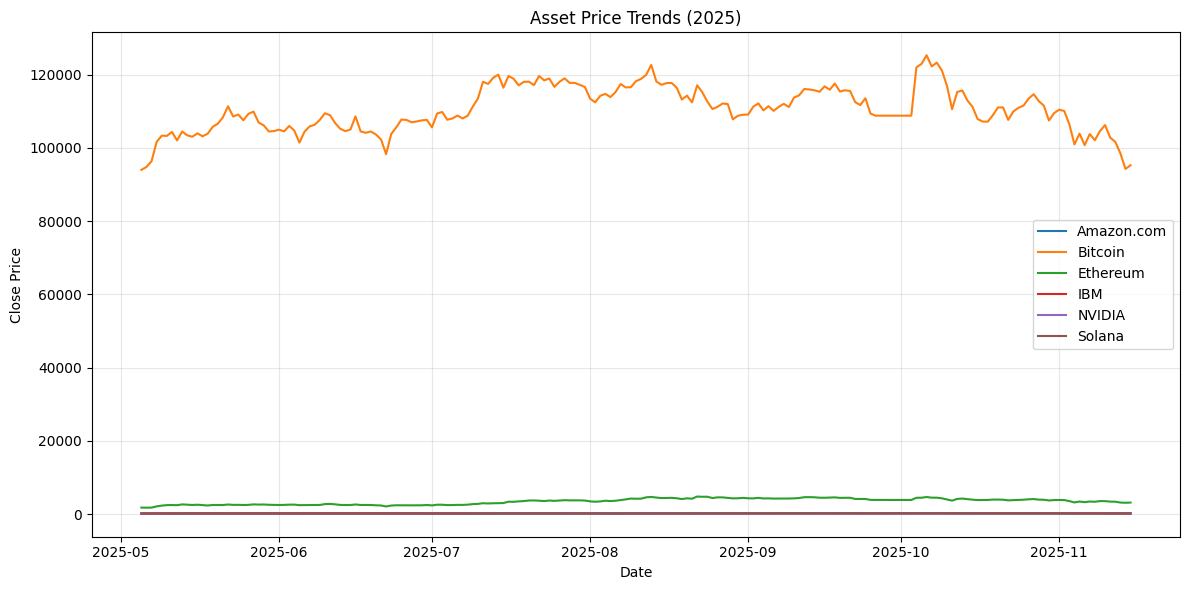

In [2]:
# Plot Closing Prices
if 'df' in locals():
    plt.figure(figsize=(12, 6))
    
    # Group by asset and plot
    for asset_name, group in df.groupby('asset_name'):
        plt.plot(group['timestamp'], group['close'], label=asset_name)
        
    plt.title("Asset Price Trends (2025)")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

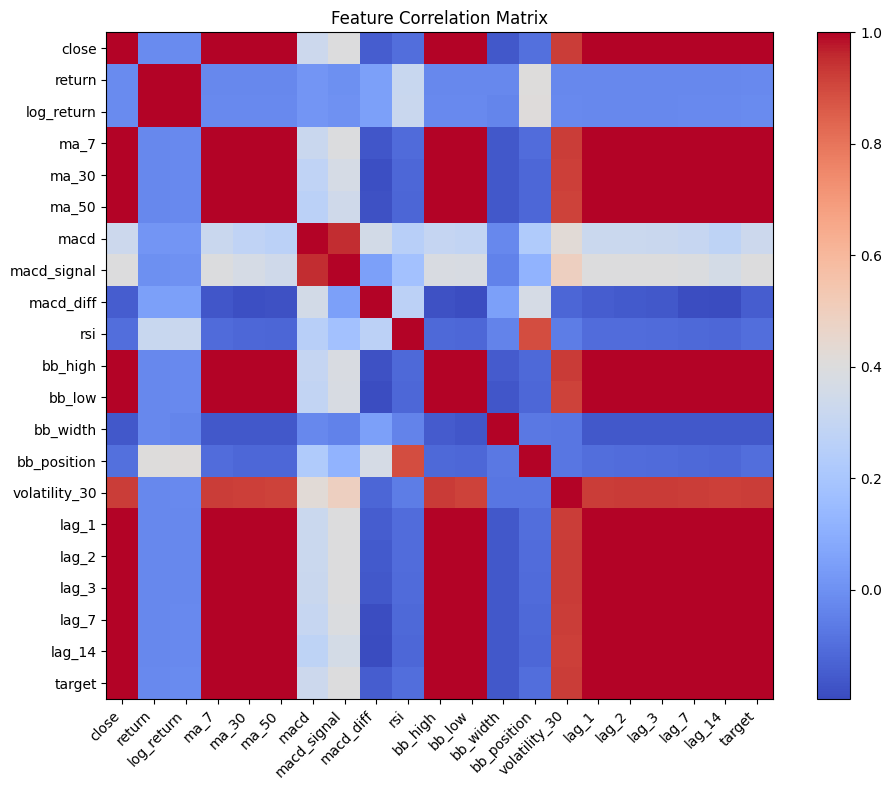

In [ ]:
# Feature Correlation Matrix
if 'df' in locals():
    numeric_cols = df.select_dtypes(include=['float64']).columns
    corr_matrix = df[numeric_cols].corr()
    
    plt.figure(figsize=(10, 8))
    plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
    plt.colorbar()
    
    # Add labels
    plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
    
    plt.title("Feature Correlation Matrix")
    plt.tight_layout()
    plt.show()